In [105]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [202]:
# load data
waterstress_data = pd.read_csv("data/AQUASTAT Dissemination System 1.csv")
waterstress_data.head()

,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
0,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2011,612.773225,current US$/inhab,X,False
1,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2012,649.710978,current US$/inhab,X,False
2,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2013,631.060444,current US$/inhab,X,False
3,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2014,596.048898,current US$/inhab,X,False
4,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2015,554.004007,current US$/inhab,X,False


In [203]:
# look at data
print(waterstress_data['Area'].unique())
print(waterstress_data['Year'].unique())
print(waterstress_data['Variable'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' "Côte d'Ivoire" "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran (

In [286]:
# pivoting data to prepare for use
df_waterstress = waterstress_data.pivot_table(
    index=["Area", "Year"],
    columns="Variable",
    values="Value"
).reset_index()

df_waterstress.head(12)

Variable,Area,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
0,Afghanistan,2011,30.613807,612.773225,44.952529,0.679890,54.757019,29347.708
1,Afghanistan,2012,30.613807,649.710978,46.809475,0.738601,54.757019,30560.034
2,Afghanistan,2013,30.613807,631.060444,48.437190,0.804276,54.757019,31622.704
3,Afghanistan,2014,30.613807,596.048898,50.229028,0.877890,54.757019,32792.523
4,Afghanistan,2015,30.613807,554.004007,51.820856,0.886913,54.757019,33831.764
5,Afghanistan,2016,30.613807,526.164709,53.151689,0.761670,54.757019,34700.612
6,Afghanistan,2017,30.613807,534.020133,54.665526,0.774685,54.757019,35688.935
7,Afghanistan,2018,30.613807,513.981256,56.280120,0.803860,54.757019,36743.039
8,Afghanistan,2019,30.613807,512.910125,57.985052,0.876542,54.757019,37856.121
9,Afghanistan,2020,30.613807,512.749930,59.842813,0.835661,54.757019,39068.979


In [296]:
# List of countries from 'Area' to exclude
excluded_regions = ['World', 'Europe', 'Asia', 'High-income countries', 'Low-income countries','European Union (27)', 
                      'Least Developed Countries', 'Western Asia', 'Sub-Saharan Africa', 'Southern Asia', 'South-eastern Asia',
                      'Oceania', 'Oceania (excluding Australia and New Zealand)', 'Northern Africa','Northern Africa and Western Asia', 'Northern America', 'Latin America and the Caribbean',
                      'Land Locked Developing Countries', 'Europe and Northern America', 'Eastern Asia', 'Eastern and South-Eastern Asia', 
                      'Central Asia','Central and Southern Asia']
df_waterstress_clean = df_waterstress[~df_waterstress["Area"].isin(excluded_regions)]

In [297]:
# check missing values
print("\nMissing values per column:")
print(df_waterstress_clean.isnull().sum())

df_waterstress_clean.describe()



Missing values per column:
Variable
Area                                                                       0
Year                                                                       0
Agricultural water withdrawal as % of total renewable water resources    282
GDP per capita                                                            72
Population density                                                        24
SDG 6.4.1. Water Use Efficiency                                          396
SDG 6.4.2. Water Stress                                                  266
Total population                                                           0
dtype: int64


Variable,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
count,2422.000000,2140.000000,2350.000000,2398.000000,2026.000000,2156.000000,2422.000000
mean,2016.504542,53.486872,8.685216,4.378812,45.183232,66.755322,8.537847
std,3.450569,308.775980,1.458989,1.379006,107.978987,305.653618,2.432428
min,2011.000000,0.000000,5.469958,1.013452,0.549735,0.027446,0.412110
25%,2014.000000,0.431897,7.584519,3.487978,6.035993,3.704729,7.340604
50%,2017.000000,1.903915,8.683715,4.418405,14.346732,10.810564,8.967766
75%,2019.750000,13.560308,9.770245,5.287434,44.868014,37.621471,10.239899
max,2022.000000,3892.000000,12.390625,9.842882,1394.294841,3850.500000,14.192697


In [355]:
# was initially trying something else,evaluating SDG measurements and nl data

# making sure 'Year' is an integer
df_waterstress_clean['Year'] = pd.to_numeric(df_waterstress_clean['Year'], errors='coerce')

# making sure 'Value' is numeric
df_waterstress_clean['SDG 6.4.2. Water Stress'] = pd.to_numeric(df_waterstress_clean['SDG 6.4.2. Water Stress'], errors='coerce')

water_stress_nl = df_waterstress_clean[(df_waterstress_clean['Area'] == 'Netherlands (Kingdom of the)')].copy()

# sort by year
water_stress_nl.sort_values(by='Year', inplace=True)

water_stress_nl.head(12)
             


Variable,Area,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population,Value
1608,Netherlands (Kingdom of the),2011,0.131209,2.476471,1.947049,61.200115,19.346877,2.373251,19.346877
1609,Netherlands (Kingdom of the),2012,0.066154,2.469746,1.947589,61.562017,20.346117,2.373605,20.346117
1610,Netherlands (Kingdom of the),2013,0.117473,2.473071,1.948025,66.555089,20.201253,2.373890,20.201253
1611,Netherlands (Kingdom of the),2014,0.090879,2.473980,1.948552,74.596901,18.017847,2.374235,18.017847
1612,Netherlands (Kingdom of the),2015,0.116374,2.460646,1.949196,80.570158,15.969242,2.374657,15.969242
1613,Netherlands (Kingdom of the),2016,0.084066,2.462241,1.950001,85.791540,15.233340,2.375184,15.233340
1614,Netherlands (Kingdom of the),2017,0.131538,2.467127,1.965727,89.527075,15.029808,2.375780,15.029808
1615,Netherlands (Kingdom of the),2018,0.331978,2.474499,1.966579,90.144370,16.366984,2.376347,16.366984
1616,Netherlands (Kingdom of the),2019,0.278462,2.473768,1.967507,88.114013,17.000607,2.376964,17.000607
1617,Netherlands (Kingdom of the),2020,0.337582,2.473385,1.968294,85.777689,16.803561,2.377488,16.803561


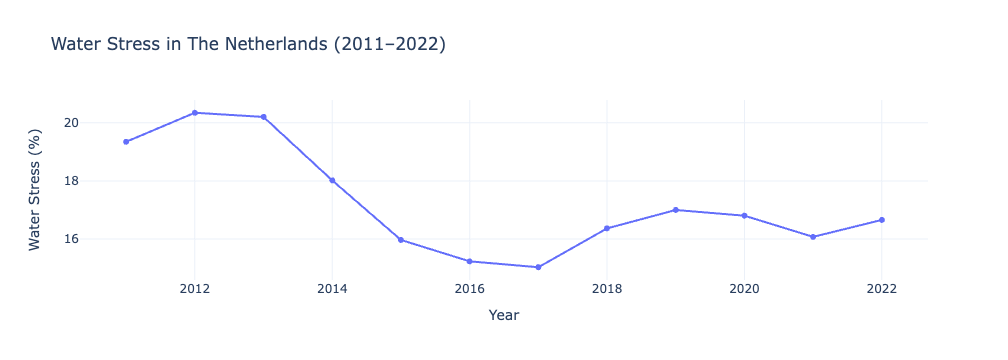

In [370]:
# visualization updated for The Netherlands Water Stress Through the Years
fig = px.line(
    water_stress_nl,
    x='Year',
    y='Value',
    title='Water Stress in The Netherlands (2011–2022)',
    labels={'Value': 'Water Stress (%)'},
    markers=True
)

fig.update_layout(template='plotly_white')

#save as interactive HTML
fig.write_html("docs/data/visual_charts_graphs/netherlands_water_stress_2011_2022.html")
fig.show()

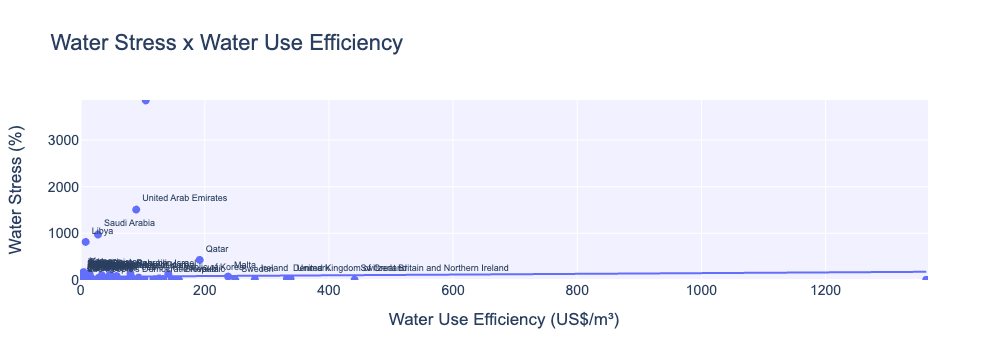

In [363]:
# visualization scatter 'water use efficiency' x 'water stress'
recent_year = df_waterstress_clean['Year'].max()
most_recent = df_waterstress_clean[df_waterstress_clean['Year'] == recent_year].copy()

# only label outliers (high water stress, very high/low water use efficiency)
high_stress = most_recent['SDG 6.4.2. Water Stress'] > 80
high_eff = most_recent['SDG 6.4.1. Water Use Efficiency'] > most_recent['SDG 6.4.1. Water Use Efficiency'].quantile(0.95)
low_eff = most_recent['SDG 6.4.1. Water Use Efficiency'] < most_recent['SDG 6.4.1. Water Use Efficiency'].quantile(0.05)

most_recent['Label'] = np.where(high_stress | high_eff | low_eff, most_recent['Area'], '')

fig = px.scatter(
    most_recent,
    x='SDG 6.4.1. Water Use Efficiency',
    y='SDG 6.4.2. Water Stress',
    text='Label', 
    trendline='ols',
    title='Water Stress x Water Use Efficiency',
    labels={
        'SDG 6.4.1. Water Use Efficiency': 'Water Use Efficiency (US$/m³)',
        'SDG 6.4.2. Water Stress': 'Water Stress (%)'
    },
)

fig.update_traces(
    textposition='top right',
    marker=dict(size=8),
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Water Stress: %{y}<br>Water Use Efficiency: %{US$/m³}<extra></extra>'
)

fig.update_layout(
    xaxis=dict(range=[-1, most_recent['SDG 6.4.1. Water Use Efficiency'].max() + 3]),
    yaxis=dict(range=[0, most_recent['SDG 6.4.2. Water Stress'].max() + 10]),
    plot_bgcolor='rgba(240,240,255,0.95)',
    title_font_size=22,
    font=dict(family="Arial", size=14)
)

fig.show()


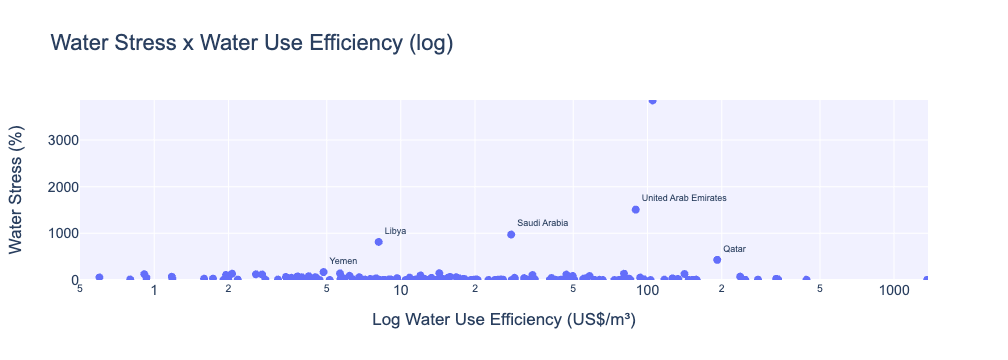

In [368]:
# visualization scatter 'water use efficiency' log scale x 'water stress' 
recent_year = df_waterstress_clean['Year'].max()
most_recent = df_waterstress_clean[df_waterstress_clean['Year'] == recent_year].copy()

# labelling certain outliers 
label_countries = ['United Arab Emirates', 'Saudi Arabia', 'Libya', 'Qatar', 'Yemen', 'Kuwait, Luxembourg']
most_recent['Label'] = most_recent['Area'].where(most_recent['Area'].isin(label_countries), '')


fig = px.scatter(
    most_recent,
    x='SDG 6.4.1. Water Use Efficiency',
    y='SDG 6.4.2. Water Stress',
    text='Label',
    title='Water Stress x Water Use Efficiency (log)',
    labels={
        'SDG 6.4.1. Water Use Efficiency': 'Log Water Use Efficiency (US$/m³)',
        'SDG 6.4.2. Water Stress': 'Water Stress (%)'
    },
    hover_name='Area'
)

fig.update_traces(
    textposition='top right',
    marker=dict(size=8),
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Water Stress: %{y:.1f}%<br>Water Use Efficiency: %{x:.2f} US$/m³<extra></extra>'
)

fig.update_layout(
    xaxis=dict(
        type='log',
        range=[np.log10(0.5), np.log10(most_recent['SDG 6.4.1. Water Use Efficiency'].max() + 10)]
    ),
    yaxis=dict(range=[0, most_recent['SDG 6.4.2. Water Stress'].max() + 10]),
    plot_bgcolor='rgba(240,240,255,0.95)',
    title_font_size=22,
    font=dict(family="Arial", size=14)
)

# save as an interactive html
fig.write_html("docs/data/visual_charts_graphs/water_stress_water_use.html", include_plotlyjs="cdn", full_html=True)
fig.show()
